# INF-616 - Tarefa 3

Professor: Alexandre Ferreira -- melloferreira@ic.unicamp.br  
Monitor: Lucas David -- ra188972@students.ic.unicamp.br

Instituto de Computação - Unicamp  
2018

In [3]:
import numpy as np
import pandas as pd
from sklearn import metrics
from sklearn.model_selection import train_test_split
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import make_pipeline
import matplotlib.pyplot as plt

from __future__ import print_function

%matplotlib inline

np.random.seed(13)

In [21]:
# O codigo abaixo ira baixar e carregar o conjunto `spambase`.
# Leia sobre este conjunto aqui: https://archive.ics.uci.edu/ml/datasets/spambase

target_names = ['not-spam', 'spam']
label_field = 'label'
attributes = ['word_freq_make', 'word_freq_address', 'word_freq_all', 'word_freq_3d',
              'word_freq_our', 'word_freq_over', 'word_freq_remove', 'word_freq_internet',
              'word_freq_order', 'word_freq_mail', 'word_freq_receive', 'word_freq_will',
              'word_freq_people', 'word_freq_report', 'word_freq_addresses', 'word_freq_free',
              'word_freq_business', 'word_freq_email', 'word_freq_you', 'word_freq_credit',
              'word_freq_your', 'word_freq_font', 'word_freq_000', 'word_freq_money',
              'word_freq_hp', 'word_freq_hpl', 'word_freq_george', 'word_freq_650',
              'word_freq_lab', 'word_freq_labs', 'word_freq_telnet', 'word_freq_857',
              'word_freq_data', 'word_freq_415', 'word_freq_85', 'word_freq_technology',
              'word_freq_1999', 'word_freq_parts', 'word_freq_pm', 'word_freq_direct',
              'word_freq_cs', 'word_freq_meeting', 'word_freq_original', 'word_freq_project',
              'word_freq_re', 'word_freq_edu', 'word_freq_table', 'word_freq_conference',
              'char_freq_;', 'char_freq_(', 'char_freq_[', 'char_freq_!', 'char_freq_$',
              'char_freq_#', 'capital_run_length_average', 'capital_run_length_longest',
              'capital_run_length_total', label_field]
features = [a for a in attributes if a != 'label']

d = pd.read_csv('https://archive.ics.uci.edu/ml/machine-learning-databases/spambase/spambase.data',
                header=None, names=attributes, delimiter=',')

Conjunto Spambase treino:
amostras: 2226
características: 57
frequência das classes: {'not-spam': 2091, 'spam': 135}
Conjunto Spambase test:
amostras: 1151
características: 57
frequência das classes: {'not-spam': 697, 'spam': 454}


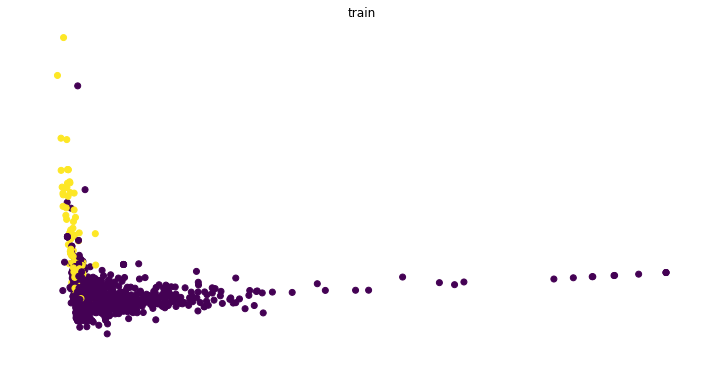

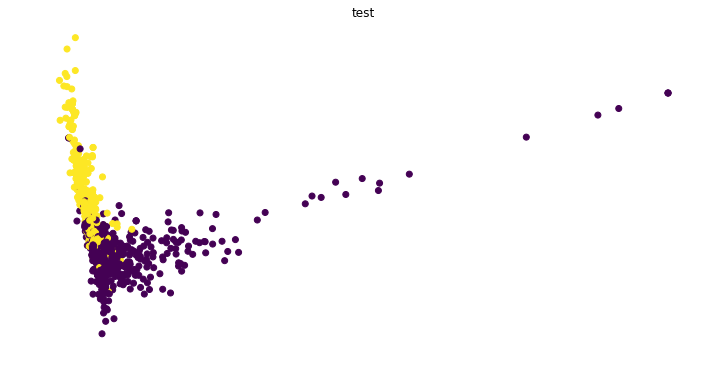

In [34]:
def describe(x, y, classes):
    """Descreve um conjunto de dados.
    
    :param x: np.ndarray, as amostras no conjunto.
    :param y: np.ndarray, os rotulos associados as amostras `x`.
    :param classes: list, uma lista com os nomes de cada classe. 
    """
    print('amostras:', x.shape[0])
    print('características:', x.shape[1])

    _, counts = np.unique(y, return_counts=True)
    print('frequência das classes:', dict(zip(classes, counts)))

def show_datasets(x, y, title):
    """Encontra um "embedding" de um conjunto que alinha as direções
       de maximiza separação das amostras com os eixos da base canônica.
    
    :param x: np.ndarray, as amostras do conjunto.
    :param y: np.ndarray, os rotulos associados as amostras `x`.
    :param title: str, o titulo do conjunto a ser exibido.
    """
    e = make_pipeline(
        StandardScaler(),
        PCA(n_components=2)
    ).fit_transform(x)

    _ = plt.figure(figsize=(12, 6))
    _ = plt.scatter(e[:, 0], e[:, 1], c=y)
    _ = plt.title(title)
    _ = plt.axis('off')

x_train, x_test, y_train, y_test = train_test_split(d[features], d['label'],
                                                    test_size=0.25,
                                                    random_state=1821)

# Seleciona 10% dos spams.
p, = np.where(y_train == 1)
np.random.shuffle(p)
p = p[:int(.1 * len(p))]
# Encontra os indices em treino que pertencem aos 10% selecionados.
p = np.in1d(np.arange(len(y_train)), p)
# Seleciona todos os nao-spam ou os 10% spams selecionados.
p = (y_train == 0) | p
# Filtra o conjunto de treino, mantendo somente os selecionados.
x_train, y_train = x_train[p], y_train[p]

print('Conjunto Spambase treino:')
describe(x_train, y_train, target_names)
print('Conjunto Spambase test:')
describe(x_test, y_test, target_names)
show_datasets(x_train, y_train, 'train')
show_datasets(x_test, y_test, 'test')

**Utilizando tudo o que você aprendeu até aqui (e.g. CV, otimização de hiper-parâmetros, regularização), defina e treine um estimador para este problema. Avalie seu estimador sobre o conjunto de teste.**

Dica: vários estimadores possuem regularizadores implementados internamente, expondo somente um parâmetro a ser ajustado. Exemplos: `KNeighborsClassifier`, `RandomForestClassifier`, `SVC`, `MLPClassifier`, `SGDClassifier`, `Perceptron`.

In [37]:
from sklearn.neural_network import MLPClassifier
from sklearn.model_selection import GridSearchCV


def train_and_report(model, train, test):
    grid = (GridSearchCV(model,
                         params,
                         cv=3,
                         n_jobs=8,
                         verbose=1)
            .fit(*train))

    print('best parameters:', grid.best_params_)
    print('best valid score:', grid.best_score_)

    p = grid.predict(test[0])

    print(metrics.classification_report(test[1], p),
          'Confusion matrix:',
          metrics.confusion_matrix(test[1], p), sep='\n')

base_network = make_pipeline(
    StandardScaler(),
    PCA(),
    MLPClassifier(early_stopping=True, validation_fraction=0.3))

params = {
    'pca__n_components': [0.95, 0.99],
    'mlpclassifier__learning_rate_init': [0.001, 0.005, 0.01, 0.05],
    'mlpclassifier__hidden_layer_sizes': [[32], [32, 32], [64, 64], [256, 256]],
    'mlpclassifier__alpha': [0.0001, .001, .01]
}

train_and_report(base_network, (x_train, y_train), (x_test, y_test))

Fitting 3 folds for each of 96 candidates, totalling 288 fits


[Parallel(n_jobs=8)]: Done  34 tasks      | elapsed:    5.4s
[Parallel(n_jobs=8)]: Done 184 tasks      | elapsed:   40.6s
[Parallel(n_jobs=8)]: Done 288 out of 288 | elapsed:  1.1min finished


best parameters: {'mlpclassifier__alpha': 0.01, 'mlpclassifier__hidden_layer_sizes': [64, 64], 'mlpclassifier__learning_rate_init': 0.005, 'pca__n_components': 0.99}
best valid score: 0.9690026954177897
             precision    recall  f1-score   support

          0       0.78      0.99      0.87       697
          1       0.98      0.57      0.72       454

avg / total       0.86      0.83      0.81      1151

Confusion matrix:
[[692   5]
 [195 259]]


**Utilize uma ou mais técnicas da biblioteca imbalanced-learn e compare os resultados com os obtidos acima**

Conjunto Spambase apos balanceamento:
amostras: 4182
características: 57
frequência das classes: {'not-spam': 2091, 'spam': 2091}
Fitting 3 folds for each of 96 candidates, totalling 288 fits


[Parallel(n_jobs=8)]: Done  34 tasks      | elapsed:   12.0s
[Parallel(n_jobs=8)]: Done 184 tasks      | elapsed:  1.6min
[Parallel(n_jobs=8)]: Done 288 out of 288 | elapsed:  2.6min finished


best parameters: {'mlpclassifier__alpha': 0.01, 'mlpclassifier__hidden_layer_sizes': [64, 64], 'mlpclassifier__learning_rate_init': 0.01, 'pca__n_components': 0.99}
best valid score: 0.9882831181252989
             precision    recall  f1-score   support

          0       0.83      0.98      0.89       697
          1       0.95      0.68      0.79       454

avg / total       0.87      0.86      0.85      1151

Confusion matrix:
[[680  17]
 [144 310]]


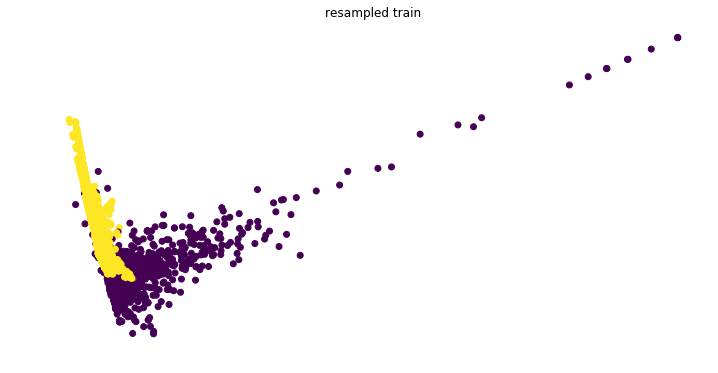

In [38]:
from imblearn.over_sampling import SMOTE

# Veja a documentação para exemplos:
# http://contrib.scikit-learn.org/imbalanced-learn/stable/introduction.html

balancer = SMOTE(random_state=85)
x_resampled_train, y_resampled_train = balancer.fit_sample(x_train, y_train)

print('Conjunto Spambase apos balanceamento:')
describe(x_resampled_train, y_resampled_train, target_names)
show_datasets(x_resampled_train, y_resampled_train, 'resampled train')
train_and_report(base_network, (x_resampled_train, y_resampled_train), (x_test, y_test))